# Differentially Private Support Vector Machine (SVM) - BRFSS 2015 Diabetes Dataset

This notebook implements a **Differentially Private SVM** using **Huber loss with objective perturbation**.

## Implementation Approach:
- Replace standard hinge loss with **Huber loss** (smooth approximation, convex and differentiable — Eq. 7 of Chaudhuri et al.)
- Apply **objective perturbation** using spherically symmetric noise ν(b) ∝ exp(−β‖b‖₂)
- Noise vector sampled via: random unit direction × Gamma(d, 1/β) radius
- Use L-BFGS-B optimization with privacy guarantees
- Privacy guarantee: Pure ε-DP via Algorithm 2 of Chaudhuri et al. (2011)

## Why this method?
- `diffprivlib` does not provide a SVM implementation
- Objective perturbation on Huber loss gives pure ε-DP (no δ term)
- L2 regularization provides strong convexity → bounded sensitivity
- Linear in n → scales to 56K training samples (unlike kernel SVM which is O(n²))
- Consistent with BCP dataset implementation for cross-dataset comparison

## 1. Import Libraries

In [1]:
import time
import os
import sys
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings('ignore')

# The DP-SVM implementation and the model exporter are shared across all
# datasets and live at the repository root.
REPO_ROOT = os.path.abspath(os.path.join('..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from common_svm import DifferentiallyPrivateSVM  # noqa: E402
from model_exporter import export_model  # noqa: E402

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
# Load the scaled data
with open("../data/processed_data.pkl", "rb") as f: 
    loaded_data = pickle.load(f)

X_train, X_test = loaded_data["X_train"], loaded_data["X_test"]
y_train, y_test = loaded_data["y_train"], loaded_data["y_test"]

# DP norm precondition: clip every row to unit L2 norm (||x_i||_2 <= 1).
X_train = X_train / np.maximum(np.linalg.norm(X_train, axis=1, keepdims=True), 1.0)
X_test = X_test / np.maximum(np.linalg.norm(X_test, axis=1, keepdims=True), 1.0)

# Convert labels to {-1, +1} for SVM
y_train_svm = 2 * y_train - 1
y_test_svm = 2 * y_test - 1

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Labels: {np.unique(y_train_svm)}")

Training set: (56553, 21)
Test set: (14139, 21)
Labels: [-1.  1.]


## 3. Load Baseline Results

In [3]:
# Load baseline results from standard model
try:
    baseline_df = pd.read_csv('./output/baseline_results.csv')
    baseline_accuracy = baseline_df['accuracy'].values[0]
    baseline_f1 = baseline_df['f1_score'].values[0]
    print("Baseline results loaded successfully!")
    print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"Baseline F1-Score: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: ./output/baseline_results.csv not found. Please run STD_SVM.ipynb first.")
    baseline_accuracy = None
    baseline_f1 = None

Baseline results loaded successfully!
Baseline Accuracy: 0.7476
Baseline F1-Score: 0.7613


## 4. Implement Differentially Private SVM with Huber Loss

### Theory (Chaudhuri et al., 2011 — Algorithm 2):
- **Huber loss** (Eq. 7): Smooth approximation of hinge loss with transition zone [1-h, 1+h]
- **Objective perturbation**: Add noise vector b with density ν(b) ∝ exp(−β‖b‖₂)
- **Noise sampling**: direction = uniform on unit sphere; radius ~ Gamma(d, 1/β)
- **ε' and Δ**: Algorithm 2 conditionally adds slack regularization Δ when ε' ≤ 0
- **Second derivative bound**: c = 1/(2h) for Huber loss
- **Privacy guarantee**: Pure ε-DP achieved through objective perturbation mechanism

**Implementation:** `DifferentiallyPrivateSVM` from `common_svm.py` at the repository root — a single shared implementation of Algorithm 2 (Chaudhuri, Monteleoni & Sarwate, JMLR 2011) used by every dataset.

`normalize=True` rescales the features by the largest training-row norm so the privacy precondition ‖x_i‖ ≤ 1 holds. The scale is folded back into the learned weights, so predictions (and the exported models) still take the unscaled features.

`fit_intercept=True` (the default) learns an unregularized bias term; the noise vector is drawn in d = n_features + 1 dimensions accordingly.

`privacy_report()` records ε′, Δ and whether Algorithm 2's fallback branch fired. When it does, the effective budget is ε/2 rather than ε — the sweep below stores this per ε in the JSON report.


## 5. Train Differentially Private SVM Model

Testing with a single epsilon value (ε=1.0) for initial evaluation.

In [4]:
# Define epsilon value for differential privacy
epsilon = 1.0
N_RUNS = 30

# Store per-run metrics for the detailed evaluation at epsilon=1.0
detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []
detail_cms = []

print(f"Training DP-SVM {N_RUNS} times with epsilon={epsilon}...")
print("=" * 60)

detail_extra = ExtraMetrics()
for run in range(N_RUNS): 
    seed = run * 10 + 42

    dp_svm = DifferentiallyPrivateSVM(
        epsilon=epsilon,
        Lambda=0.01,
        h=0.5,
        normalize=True,
        random_state=seed
    )

    _t0 = time.perf_counter()
    dp_svm.fit(X_train, y_train_svm)
    train_time = time.perf_counter() - _t0

    # Predict (returns {-1, +1}, convert back to {0, 1})
    y_dp_pred_svm = dp_svm.predict(X_test)
    y_dp_pred = (y_dp_pred_svm + 1) // 2

    dp_accuracy = accuracy_score(y_test, y_dp_pred)
    detail_extra.add(y_test, y_dp_pred, model=dp_svm, X=X_test, train_time=train_time)
    dp_f1 = f1_score(y_test, y_dp_pred)
    dp_precision = precision_score(y_test, y_dp_pred, zero_division=0)
    dp_recall = recall_score(y_test, y_dp_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_dp_pred)

    detail_accuracies.append(dp_accuracy)
    detail_f1s.append(dp_f1)
    detail_precisions.append(dp_precision)
    detail_recalls.append(dp_recall)
    detail_cms.append(cm)

    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {dp_accuracy:.4f} | F1: {dp_f1:.4f} | Prec: {dp_precision:.4f} | Rec: {dp_recall:.4f}")

print("Added metrics over the detail runs:")
print(detail_extra.describe())

Training DP-SVM 30 times with epsilon=1.0...
  Run  1/30 | Acc: 0.7261 | F1: 0.7372 | Prec: 0.7084 | Rec: 0.7684
  Run  2/30 | Acc: 0.7261 | F1: 0.7373 | Prec: 0.7082 | Rec: 0.7688
  Run  3/30 | Acc: 0.7259 | F1: 0.7371 | Prec: 0.7083 | Rec: 0.7683
  Run  4/30 | Acc: 0.7265 | F1: 0.7375 | Prec: 0.7090 | Rec: 0.7683
  Run  5/30 | Acc: 0.7265 | F1: 0.7375 | Prec: 0.7090 | Rec: 0.7683
  Run  6/30 | Acc: 0.7260 | F1: 0.7371 | Prec: 0.7083 | Rec: 0.7684
  Run  7/30 | Acc: 0.7262 | F1: 0.7373 | Prec: 0.7086 | Rec: 0.7684
  Run  8/30 | Acc: 0.7261 | F1: 0.7373 | Prec: 0.7084 | Rec: 0.7686
  Run  9/30 | Acc: 0.7260 | F1: 0.7371 | Prec: 0.7083 | Rec: 0.7684
  Run 10/30 | Acc: 0.7265 | F1: 0.7377 | Prec: 0.7086 | Rec: 0.7693
  Run 11/30 | Acc: 0.7256 | F1: 0.7368 | Prec: 0.7078 | Rec: 0.7683
  Run 12/30 | Acc: 0.7261 | F1: 0.7373 | Prec: 0.7084 | Rec: 0.7687
  Run 13/30 | Acc: 0.7264 | F1: 0.7374 | Prec: 0.7089 | Rec: 0.7684
  Run 14/30 | Acc: 0.7264 | F1: 0.7373 | Prec: 0.7089 | Rec: 0.7681
  R

## 6. Model Evaluation

In [5]:
avg_accuracy = float(np.mean(detail_accuracies))
avg_f1_score = float(np.mean(detail_f1s))
avg_precision = float(np.mean(detail_precisions))
avg_recall = float(np.mean(detail_recalls))

std_accuracy = float(np.std(detail_accuracies))
std_f1_score = float(np.std(detail_f1s))
std_precision = float(np.std(detail_precisions))
std_recall = float(np.std(detail_recalls))

print("=" * 60)
print(f"\nResults over {N_RUNS} runs at epsilon={epsilon}:")
print(f"  Accuracy:  {avg_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"  F1-Score:  {avg_f1_score:.4f} ± {std_f1_score:.4f}")
print(f"  Precision: {avg_precision:.4f} ± {std_precision:.4f}")
print(f"  Recall:    {avg_recall:.4f} ± {std_recall:.4f}")


Results over 30 runs at epsilon=1.0:
  Accuracy:  0.7262 ± 0.0003
  F1-Score:  0.7373 ± 0.0002
  Precision: 0.7085 ± 0.0004
  Recall:    0.7686 ± 0.0003


## 7. Confusion Matrix

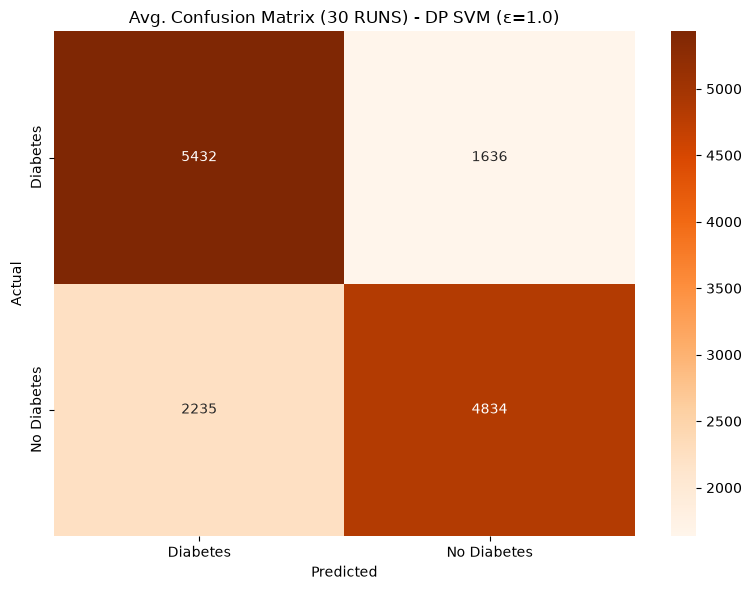


Confusion Matrix:
[[5432 1636]
 [2235 4834]]


In [6]:
avg_cm = np.mean(detail_cms, axis=0).astype(int)

TN = avg_cm[0, 0]
FP = avg_cm[0, 1]
FN = avg_cm[1, 0]
TP = avg_cm[1, 1]

custom_cm = np.array([
    [TP, FN], 
    [FP, TN]
])

plt.figure(figsize=(8, 6))
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Diabetes', 'No Diabetes'],
            yticklabels=['Diabetes', 'No Diabetes'])
plt.title(f'Avg. Confusion Matrix ({N_RUNS} RUNS) - DP SVM (ε={epsilon})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(custom_cm)

## 8. Compare with Baseline (Standard Model)

In [7]:
if baseline_accuracy is not None:
    accuracy_loss = baseline_accuracy - avg_accuracy
    f1_loss = baseline_f1 - avg_f1_score
    
    print("=" * 50)
    print("COMPARISON: Standard vs DP SVM")
    print("=" * 50)
    print(f"\nStandard Model Accuracy: {baseline_accuracy:.4f}")
    print(f"DP Model Accuracy (avg): {avg_accuracy:.4f}")
    print(f"Accuracy Loss:           {accuracy_loss:.4f} ({accuracy_loss*100:.2f}%)")
    print(f"\nStandard Model F1-Score: {baseline_f1:.4f}")
    print(f"DP Model F1-Score (avg): {avg_f1_score:.4f}")
    print(f"F1 Loss:                 {f1_loss:.4f} ({f1_loss*100:.2f}%)")
else:
    print("Baseline results not available. Run STD_SVM.ipynb first.")

COMPARISON: Standard vs DP SVM

Standard Model Accuracy: 0.7476
DP Model Accuracy (avg): 0.7262
Accuracy Loss:           0.0214 (2.14%)

Standard Model F1-Score: 0.7613
DP Model F1-Score (avg): 0.7373
F1 Loss:                 0.0240 (2.40%)


## 9. Prepare JSON Report Structure

In [8]:
N_RUNS = 30

parameters = {
    "model": "DP-SVM with Huber Loss (Chaudhuri et al. 2011, Algorithm 2)",
    "Lambda": 0.01,
    "h": 0.5,
    "method": "Objective Perturbation (L2-norm spherical noise, ν(b) ∝ exp(-β‖b‖₂))",
    "optimizer": "L-BFGS-B",
    "n_runs": N_RUNS,
}

results_json = {
    "model_type": "Differentially Private SVM (Huber Loss + Objective Perturbation, Algorithm 2)",
    "dataset": "BRFSS 2015 Diabetes",
    "n_runs_per_epsilon": N_RUNS,
    "epsilon_results": {}
}

## 10. Epsilon vs Accuracy Analysis

Testing different privacy budget (epsilon) values to observe the trade-off between privacy and accuracy.

In [9]:
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]

# Store aggregated results
results = {
    'epsilon': [],
    'accuracy_mean': [],
    'accuracy_std': [],
    'f1_score_mean': [],
    'f1_score_std': [],
    'precision_mean': [],
    'precision_std': [],
    'recall_mean': [],
    'recall_std': [],
}

print(f"Training DP-SVM with {N_RUNS} runs per epsilon value...")
print("=" * 80)

for eps in epsilon_values:
    run_accuracies = []
    run_f1s = []
    run_precisions = []
    run_recalls = []
    run_cms = []

    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42

        dp_svm = DifferentiallyPrivateSVM(
            epsilon=eps,
            Lambda=0.01,
            h=0.5,
            normalize=True,
            random_state=seed
        )
        _t0 = time.perf_counter()
        dp_svm.fit(X_train, y_train_svm)
        train_time = time.perf_counter() - _t0
        y_pred_svm = dp_svm.predict(X_test)
        y_pred = (y_pred_svm + 1) // 2

        acc = accuracy_score(y_test, y_pred)
        extra.add(y_test, y_pred, model=dp_svm, X=X_test, train_time=train_time)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        cm = confusion_matrix(y_test, y_pred)

        run_accuracies.append(acc)
        run_f1s.append(f1)
        run_precisions.append(prec)
        run_recalls.append(rec)
        run_cms.append(cm.tolist())
        
        # Export model for MIA (only first run per epsilon)
        if run == 0:
            export_model(dp_svm, f'output/model/dp_svm_model_eps_{eps}.pkl')
            privacy = dp_svm.privacy_report()

    # Compute statistics
    acc_mean, acc_std = np.mean(run_accuracies), np.std(run_accuracies)
    f1_mean, f1_std = np.mean(run_f1s), np.std(run_f1s)
    prec_mean, prec_std = np.mean(run_precisions), np.std(run_precisions)
    rec_mean, rec_std = np.mean(run_recalls), np.std(run_recalls)

    results['epsilon'].append(eps)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(prec_mean)
    results['precision_std'].append(prec_std)
    results['recall_mean'].append(rec_mean)
    results['recall_std'].append(rec_std)

    results_json["epsilon_results"][str(eps)] = {
        "epsilon": float(eps),
        "n_runs": N_RUNS,
        "accuracy_mean": acc_mean,
        "accuracy_std": acc_std,
        "f1_mean": f1_mean,
        "f1_std": f1_std,
        "precision_mean": prec_mean,
        "precision_std": prec_std,
        "recall_mean": rec_mean,
        "recall_std": rec_std,
        "per_run_accuracies": run_accuracies,
        "per_run_f1s": run_f1s,
        "per_run_precisions": run_precisions,
        "per_run_recalls": run_recalls,
        "per_run_confusion_matrices": run_cms,
        "parameters": parameters.copy(),
        "privacy": privacy
    }
    results_json["epsilon_results"][str(eps)].update(extra.summary())
    results_json["epsilon_results"][str(eps)].update(extra.per_run())

    print(f"ε={eps:5.1f} | Acc: {acc_mean:.4f}±{acc_std:.4f} | "
          f"F1: {f1_mean:.4f}±{f1_std:.4f} | "
          f"Prec: {prec_mean:.4f}±{prec_std:.4f} | "
          f"Rec: {rec_mean:.4f}±{rec_std:.4f}")

    if privacy['fallback_triggered']:
        print(f"        Algorithm 2 fallback fired: effective \u03b5' ="
              f" {privacy['eps_prime']:.4f}, \u0394 = {privacy['Delta']:.6f}")

print("=" * 80)
print("Training complete!")

Training DP-SVM with 30 runs per epsilon value...
Model successfully exported to output/model/dp_svm_model_eps_0.1.pkl
ε=  0.1 | Acc: 0.7255±0.0018 | F1: 0.7362±0.0016 | Prec: 0.7085±0.0027 | Rec: 0.7663±0.0038
Model successfully exported to output/model/dp_svm_model_eps_0.2.pkl
ε=  0.2 | Acc: 0.7260±0.0011 | F1: 0.7370±0.0009 | Prec: 0.7085±0.0018 | Rec: 0.7678±0.0019
Model successfully exported to output/model/dp_svm_model_eps_0.4.pkl
ε=  0.4 | Acc: 0.7261±0.0006 | F1: 0.7372±0.0004 | Prec: 0.7085±0.0010 | Rec: 0.7683±0.0010
Model successfully exported to output/model/dp_svm_model_eps_0.6.pkl
ε=  0.6 | Acc: 0.7261±0.0004 | F1: 0.7372±0.0003 | Prec: 0.7085±0.0006 | Rec: 0.7684±0.0007
Model successfully exported to output/model/dp_svm_model_eps_0.8.pkl
ε=  0.8 | Acc: 0.7262±0.0004 | F1: 0.7373±0.0003 | Prec: 0.7085±0.0005 | Rec: 0.7685±0.0005
Model successfully exported to output/model/dp_svm_model_eps_1.0.pkl
ε=  1.0 | Acc: 0.7262±0.0003 | F1: 0.7373±0.0002 | Prec: 0.7085±0.0004 | Rec

## 11. Save Results to JSON

In [10]:
os.makedirs('output', exist_ok=True)

with open('./output/dp_svm_report.json', 'w') as f:
    json.dump(results_json, f, indent=4)

print("Results saved to './output/dp_svm_report.json'")
print(f"Total epsilon values: {len(results_json['epsilon_results'])}")

Results saved to './output/dp_svm_report.json'
Total epsilon values: 15


## 12. Create Results DataFrame with Accuracy Loss

In [11]:
results_df = pd.DataFrame(results)
 
if baseline_accuracy is not None:
    results_df['accuracy_loss_mean'] = baseline_accuracy - results_df['accuracy_mean']
    results_df['accuracy_loss_pct'] = results_df['accuracy_loss_mean'] * 100
 
print(f"\nResults Summary ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))


Results Summary (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.725506      0.001752       0.736248      0.001587        0.708490       0.002677     0.766294    0.003785                0.725509               0.001752      0.799217     0.001789         0.021898        0.004826            0.022071           2.207134
     0.2       0.725971      0.001139       0.736953      0.000855        0.708517       0.001773     0.767775    0.001892                0.725974               0.001139      0.799430     0.000871         0.021253        0.000433            0.021607           2.160690
     0.4       0.726148      0.000603       0.737208      0.000428        0.708546       0.000967     0.768289    0.000991                0.726151       

## 13. Visualization: Privacy Budget vs Accuracy

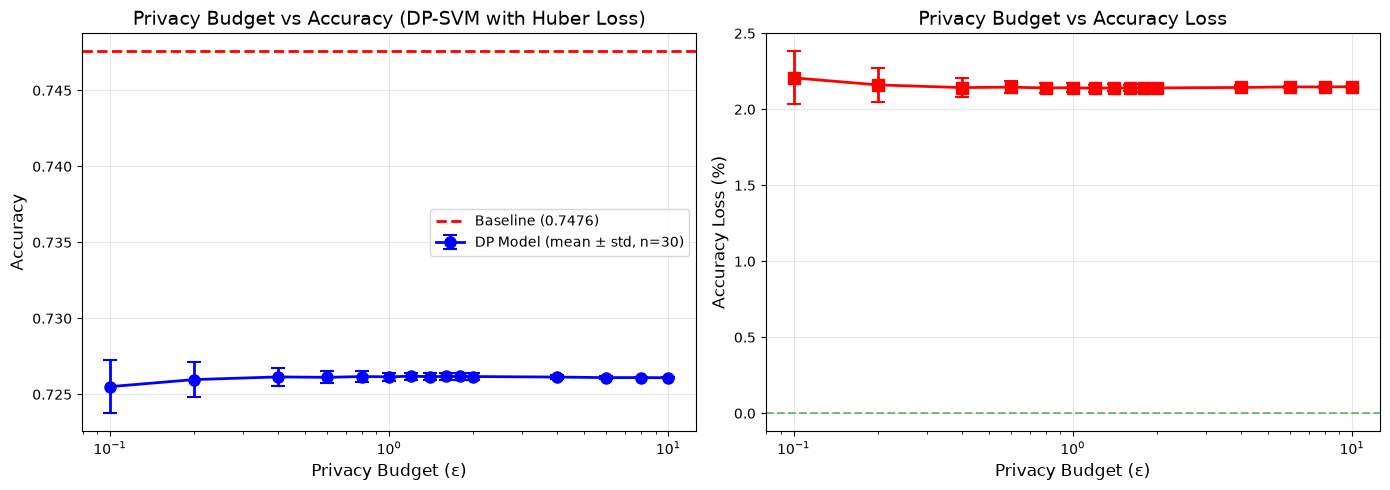


Plot saved as './output/privacy_accuracy_tradeoff.png'


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Epsilon vs Accuracy
ax1 = axes[0]
ax1.errorbar(
    results_df['epsilon'],
    results_df['accuracy_mean'],
    yerr=results_df['accuracy_std'],
    fmt='bo-', linewidth=2, markersize=8,
    capsize=5, capthick=1.5,
    label=f'DP Model (mean ± std, n={N_RUNS})'
)
if baseline_accuracy is not None:
    ax1.axhline(y=baseline_accuracy, color='r', linestyle='--',
                linewidth=2, label=f'Baseline ({baseline_accuracy:.4f})')
ax1.set_xlabel('Privacy Budget (ε)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Privacy Budget vs Accuracy (DP-SVM with Huber Loss)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# Plot 2: Epsilon vs Accuracy Loss
if baseline_accuracy is not None:
    ax2 = axes[1]
    ax2.errorbar(
        results_df['epsilon'],
        results_df['accuracy_loss_pct'],
        yerr=results_df['accuracy_std'] * 100,
        fmt='rs-', linewidth=2, markersize=8,
        capsize=5, capthick=1.5
    )
    ax2.set_xlabel('Privacy Budget (ε)', fontsize=12)
    ax2.set_ylabel('Accuracy Loss (%)', fontsize=12)
    ax2.set_title('Privacy Budget vs Accuracy Loss', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    ax2.axhline(y=0, color='g', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('./output/privacy_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as './output/privacy_accuracy_tradeoff.png'")

## 14. All Metrics vs Epsilon

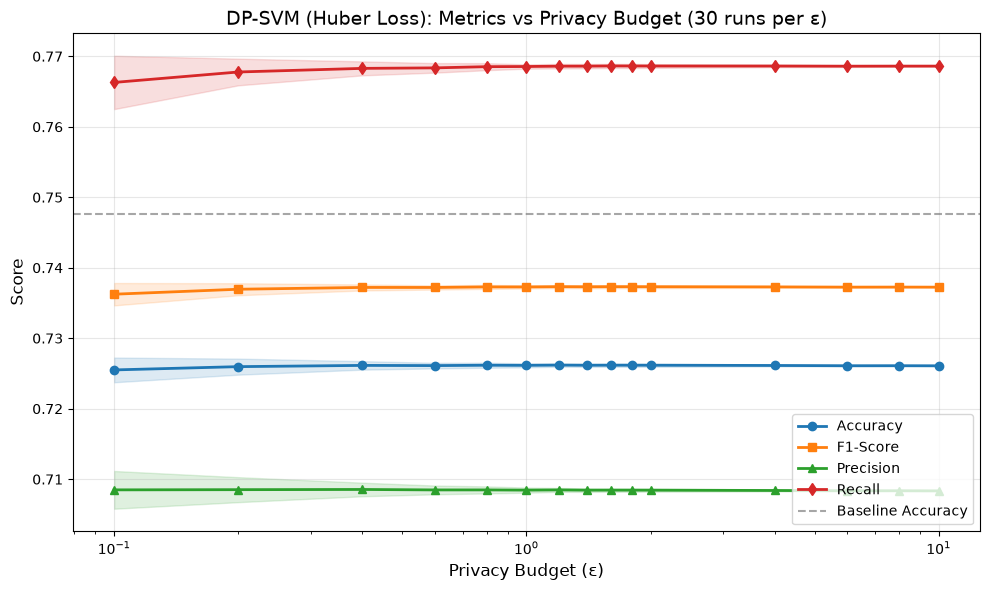

Plot saved as './output/all_metrics_vs_epsilon.png'


In [13]:
plt.figure(figsize=(10, 6))

metrics = [
    ('accuracy_mean', 'accuracy_std', 'Accuracy', 'o-'),
    ('f1_score_mean', 'f1_score_std', 'F1-Score', 's-'),
    ('precision_mean', 'precision_std', 'Precision', '^-'),
    ('recall_mean', 'recall_std', 'Recall', 'd-'),
]

for mean_col, std_col, label, fmt in metrics:
    mean_vals = results_df[mean_col].values
    std_vals = results_df[std_col].values
    eps_vals = results_df['epsilon'].values

    line = plt.plot(eps_vals, mean_vals, fmt, label=label, linewidth=2)
    color = line[0].get_color()

    plt.fill_between(
        eps_vals,
        mean_vals - std_vals,
        mean_vals + std_vals,
        alpha=0.15,
        color=color
    )

if baseline_accuracy is not None:
    plt.axhline(y=baseline_accuracy, color='gray', linestyle='--',
                alpha=0.7, label='Baseline Accuracy')

plt.xlabel('Privacy Budget (ε)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title(f'DP-SVM (Huber Loss): Metrics vs Privacy Budget ({N_RUNS} runs per ε)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.savefig('./output/all_metrics_vs_epsilon.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as './output/all_metrics_vs_epsilon.png'")

## 15. Calculate ACL (Accuracy Loss) Metric

In [14]:
if baseline_accuracy is not None:
    # Calculate ACL as defined in the paper
    # ACL = 1 - (Accuracy(M, ε) / Accuracy(M, ε=∞))
    results_df['ACL'] = 1 - (results_df['accuracy_mean'] / baseline_accuracy)
    
    print("\n" + "=" * 60)
    print("ACL (Accuracy Loss) Analysis")
    print("=" * 60)
    print(f"\nBaseline Accuracy (ε=∞): {baseline_accuracy:.4f}")
    print(f"\nACL by Privacy Budget:")
    print(results_df[['epsilon', 'accuracy_mean', 'ACL']].to_string(index=False))
    
    # Find optimal epsilon (minimum ACL)
    optimal_idx = results_df['ACL'].idxmin()
    optimal_epsilon = results_df.loc[optimal_idx, 'epsilon']
    optimal_acl = results_df.loc[optimal_idx, 'ACL']
    
    print(f"\nOptimal Privacy Budget: ε={optimal_epsilon:.1f}")
    print(f"Minimum ACL: {optimal_acl:.4f}")


ACL (Accuracy Loss) Analysis

Baseline Accuracy (ε=∞): 0.7476

ACL by Privacy Budget:
 epsilon  accuracy_mean      ACL
     0.1       0.725506 0.029524
     0.2       0.725971 0.028903
     0.4       0.726148 0.028666
     0.6       0.726119 0.028704
     0.8       0.726171 0.028635
     1.0       0.726155 0.028657
     1.2       0.726192 0.028606
     1.4       0.726166 0.028641
     1.6       0.726178 0.028625
     1.8       0.726176 0.028628
     2.0       0.726171 0.028635
     4.0       0.726138 0.028679
     6.0       0.726100 0.028729
     8.0       0.726105 0.028723
    10.0       0.726091 0.028742

Optimal Privacy Budget: ε=1.2
Minimum ACL: 0.0286


## 16. Save Final Results

In [15]:
results_df.to_csv('./output/dp_results.csv', index=False)
print("DP results saved to './output/dp_results.csv'")

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
if baseline_accuracy is not None:
    print(f"\nBaseline (Standard SVM) Accuracy: {baseline_accuracy:.4f}")
print(f"\nDP-SVM Results ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))

print("\n" + "=" * 60)
print("IMPLEMENTATION DETAILS")
print("=" * 60)
print("Method: Objective Perturbation with Huber Loss (Algorithm 2, Chaudhuri et al. 2011)")
print("Privacy Mechanism: Spherical noise ν(b) ∝ exp(-β‖b‖₂) (Pure ε-DP)")
print("Noise Sampling: direction = unit sphere; radius ~ Gamma(d, 1/β)")
print(f"Regularization (Λ): {parameters['Lambda']}")
print(f"Huber h: {parameters['h']}")
print(f"Second derivative bound c = 1/(2h) = {1.0/(2.0*parameters['h']):.4f}")
print("Optimization: L-BFGS-B")
print(f"N_RUNS per epsilon: {N_RUNS}")
print(f"Reference: Chaudhuri et al. (2011)")

DP results saved to './output/dp_results.csv'

FINAL SUMMARY

Baseline (Standard SVM) Accuracy: 0.7476

DP-SVM Results (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct      ACL
     0.1       0.725506      0.001752       0.736248      0.001587        0.708490       0.002677     0.766294    0.003785                0.725509               0.001752      0.799217     0.001789         0.021898        0.004826            0.022071           2.207134 0.029524
     0.2       0.725971      0.001139       0.736953      0.000855        0.708517       0.001773     0.767775    0.001892                0.725974               0.001139      0.799430     0.000871         0.021253        0.000433            0.021607           2.160690 0.028903
     0.4       0.726148 